# Phase 2 — Exploratory Data Analysis


**Input:**  `outputs/model_table.csv` -
**Output:** Engineered `model_table.csv` 

In [150]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [151]:
df=pd.read_csv("../outputs/model_table.csv")
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            25000 non-null  int64  
 1   age                   25000 non-null  int64  
 2   gender                25000 non-null  object 
 3   city                  25000 non-null  object 
 4   insurance_provider    25000 non-null  object 
 5   chronic_flag          25000 non-null  int64  
 6   registration_date     25000 non-null  object 
 7   visit_id              25000 non-null  int64  
 8   visit_date            25000 non-null  object 
 9   department            25000 non-null  object 
 10  visit_type            25000 non-null  object 
 11  length_of_stay_hours  25000 non-null  float64
 12  risk_score            25000 non-null  object 
 13  doctor_id             25000 non-null  int64  
 14  bill_id               25000 non-null  int64  
 15  billed_amount      

In [152]:
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] =pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

In [153]:
df.describe(include= "all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2502.20312,1.0,1263.0,2503.0,3755.0,5000.0,1443.378814
age,25000.0,NaN,NaN,NaN,44.89464,1.0,22.0,45.0,67.0,90.0,25.858097
gender,25000,2,M,12732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Bangalore,4328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,HealthPlus,6499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.49948,0.0,0.0,0.0,1.0,1.0,0.50001
registration_date,25000,NaN,NaN,NaN,2025-07-20 16:04:30.720000256,2025-01-20 00:00:00,2025-04-19 00:00:00,2025-07-18 00:00:00,2025-10-21 00:00:00,2026-01-19 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-10-20 07:55:39.647999744,2025-01-21 00:00:00,2025-09-01 00:00:00,2025-11-12 00:00:00,2025-12-27 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,5757,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribution Analysis

### Step 1 - Missing Values Analysis

In [154]:
df.isnull().sum().sort_values(ascending=False)

payment_days            9532
approved_amount         6156
patient_id                 0
age                        0
claim_status               0
billed_amount              0
bill_id                    0
doctor_id                  0
risk_score                 0
length_of_stay_hours       0
visit_type                 0
department                 0
visit_date                 0
visit_id                   0
registration_date          0
chronic_flag               0
insurance_provider         0
city                       0
gender                     0
billing_date               0
dtype: int64

In [155]:
df.head()

,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,2,15,F,Mumbai,CareOne,0,2025-12-27,8,2026-01-01,General,OPD,9.63,Low,105,8,9612.77,NaN,Rejected,NaN,2026-01-19
1,12,3,M,Bangalore,CareOne,0,2025-08-13,65,2026-01-01,ICU,ICU,59.60,High,112,65,88539.01,NaN,Rejected,NaN,2026-01-05
2,129,44,M,Pune,MediCareX,1,2025-07-20,651,2026-01-01,ICU,ER,59.28,High,150,651,88539.01,NaN,Pending,NaN,2026-01-20
3,133,47,F,Delhi,CareOne,1,2025-11-02,670,2026-01-01,General,OPD,25.15,Medium,145,670,20958.52,20322.91,Paid,48.0,2026-01-15
4,139,14,F,Chennai,SecureLife,1,2025-02-05,706,2026-01-01,Cardiology,ER,42.88,Medium,148,706,74921.48,72277.09,Paid,27.0,2026-01-16


### Step 2 — Business Logic Validation


In [156]:
# Check A - Paid claims should always have an approved amount
df[
    (df["claim_status"]=="paid") &
    (df["approved_amount"].isna())

].shape

(0, 20)

In [157]:
# Check B - payment days missing breakdown by claim status
df[df["payment_days"].isna()]["claim_status"].value_counts()

claim_status
Rejected    5266
Pending     4266
Name: count, dtype: int64

In [158]:
# Check C - LOS should never be negative
(df["length_of_stay_hours"]<0).sum()

0

### Step 3 — Distribution Analysis

In [159]:
# Categorical column reports
print("======= Department================")
print(df["department"].value_counts())
print("\n======Visit Type=================")
print(df["visit_type"].value_counts())
print("\n=======Insurance provider=========")
print(df["insurance_provider"].value_counts())
print("\n=======City=======================")
print(df["city"].value_counts())

======= Department================
department
General        5757
Orthopedics    4474
Cardiology     4071
ER             3896
ICU            3415
Neurology      3387
Name: count, dtype: int64

======Visit Type=================
visit_type
OPD    14635
ER      5778
ICU     4587
Name: count, dtype: int64

=======Insurance provider=========
insurance_provider
HealthPlus    6499
CareOne       6326
SecureLife    6197
MediCareX     5978
Name: count, dtype: int64

=======City=======================
city
Bangalore    4328
Mumbai       4267
Pune         4230
Delhi        4170
Hyderabad    4129
Chennai      3876
Name: count, dtype: int64


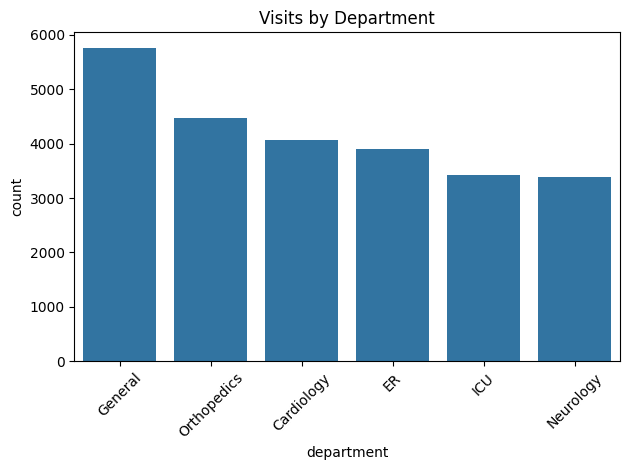

In [160]:
# Barchart showing visits by department
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

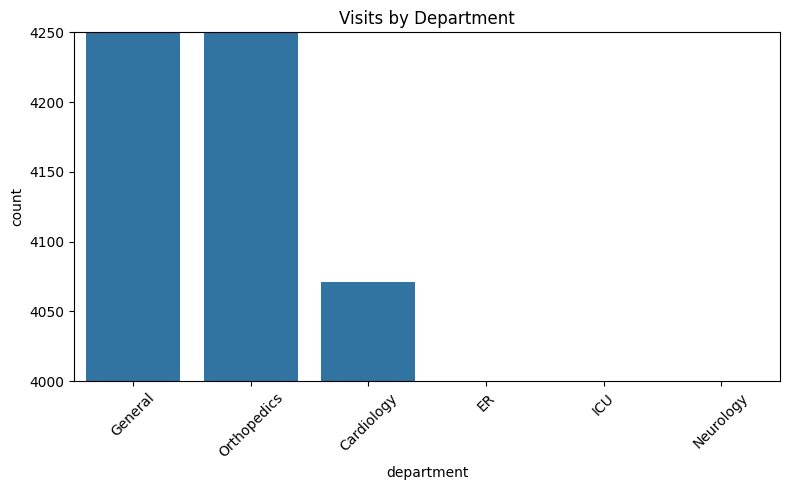

In [161]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="department",
    order=df["department"].value_counts().index
)

plt.ylim(4000, 4250)  # Zoom in
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

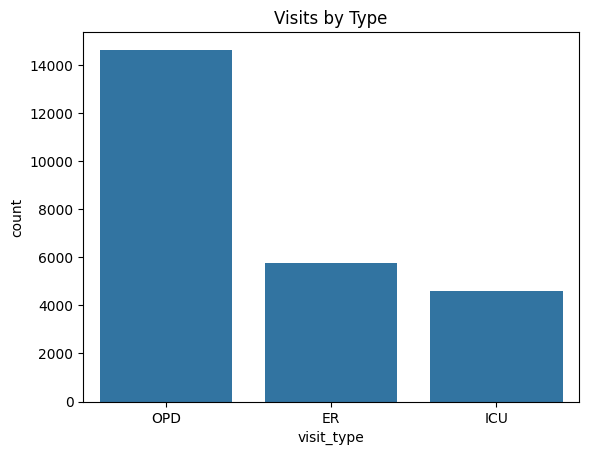

In [162]:
# Visits by Type
sns.countplot(data=df, x="visit_type", order=df["visit_type"].value_counts().index)
plt.title("Visits by Type")
plt.show()

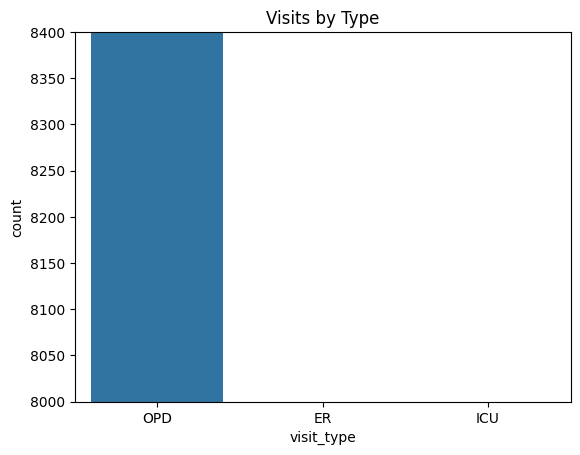

In [163]:
sns.countplot(data=df, x="visit_type", order=df["visit_type"].value_counts().index)
plt.title("Visits by Type")
plt.ylim(8000, 8400)  # Zoom in
plt.show()

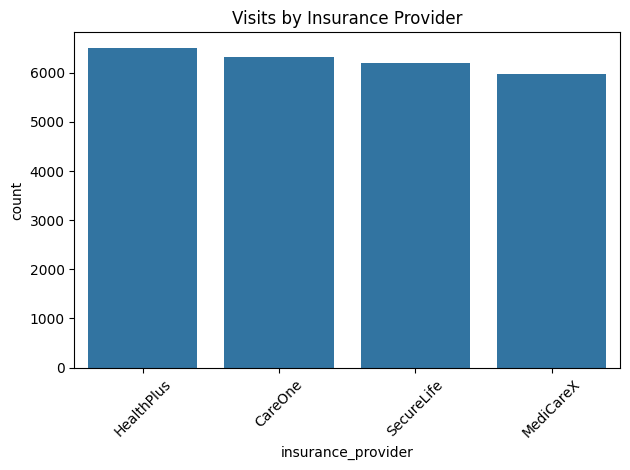

In [164]:
sns.countplot(data=df, x="insurance_provider", order=df["insurance_provider"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Insurance Provider")
plt.tight_layout()
plt.show()

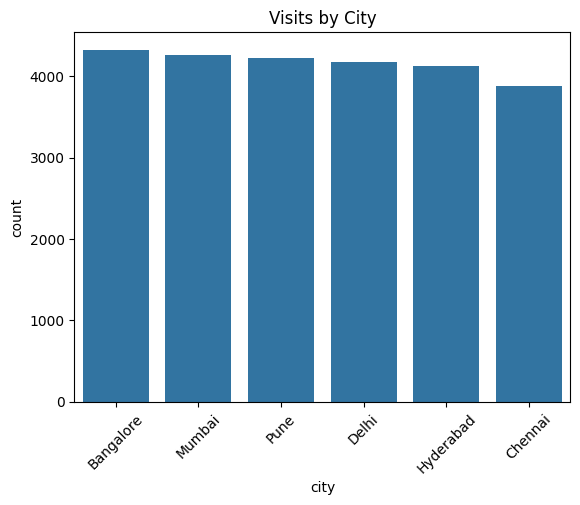

In [165]:
# Visits by City
sns.countplot(
    data=df,
    x="city",
    order=df["city"].value_counts().index
)
plt.title("Visits by City")
plt.xticks(rotation=45)
plt.show()

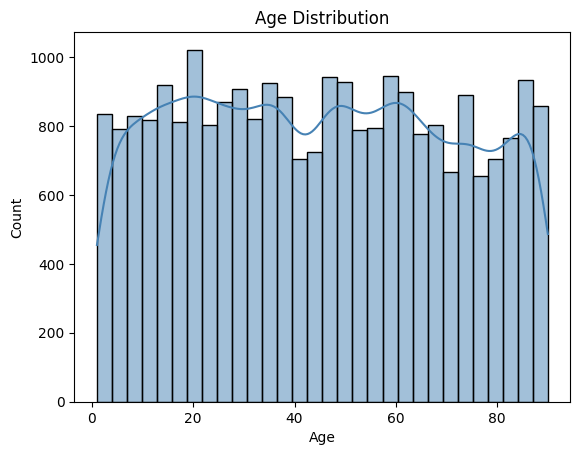

count    25000.000000
mean        44.894640
std         25.858097
min          1.000000
25%         22.000000
50%         45.000000
75%         67.000000
max         90.000000
Name: age, dtype: float64


In [166]:
# Age Dsitribution
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df["age"].describe())


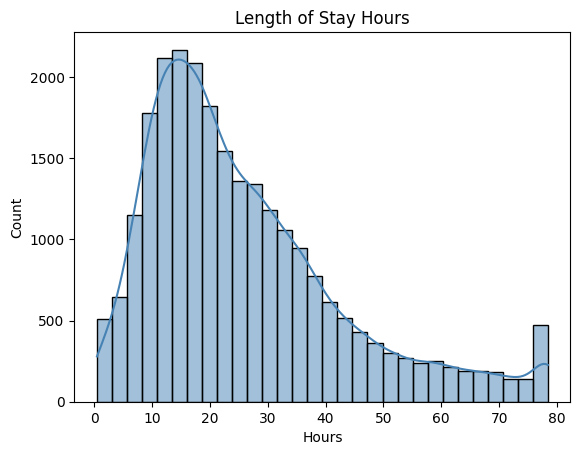

count    25000.00
mean        26.03
std         17.15
min          0.50
25%         13.54
50%         21.61
75%         34.22
max         78.42
Name: length_of_stay_hours, dtype: float64


In [167]:
# Length of Stay Distribution
sns.histplot(df["length_of_stay_hours"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay Hours")
plt.xlabel("Hours")
plt.show()
print(df["length_of_stay_hours"].describe().round(2))

In [168]:
firstIQR=9.96
thirdIQR=27.31
IQR=thirdIQR-firstIQR
upper_bound=thirdIQR+(1.5*IQR) 
print(f"Upper bound for LOS hours: {upper_bound:.2f}")
lower_bound=firstIQR-(1.5*IQR)
print(f"Lower bound for LOS hours: {lower_bound:.2f}")

Upper bound for LOS hours: 53.33
Lower bound for LOS hours: -16.06


## Outlier Detection

### Step 4 — Outlier Detection

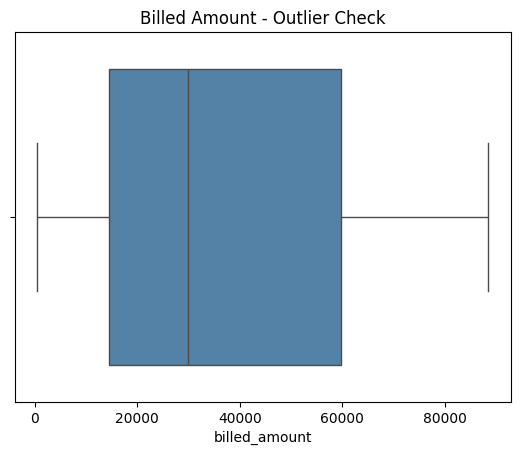

In [169]:
sns.boxplot(x=df["billed_amount"], color="steelblue")
plt.title("Billed Amount - Outlier Check") # Focus on typical range
plt.show()

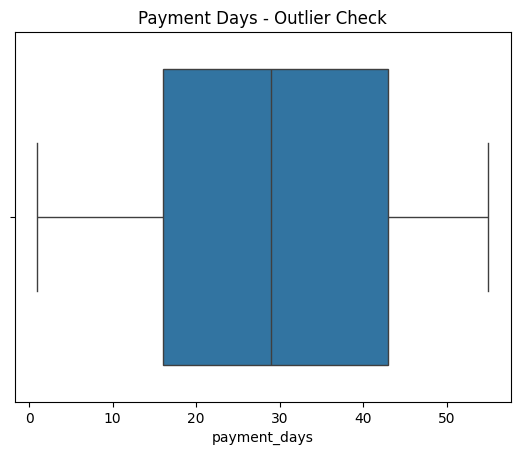

In [170]:
sns.boxplot(x=df["payment_days"])
plt.title("Payment Days - Outlier Check")
plt.show()

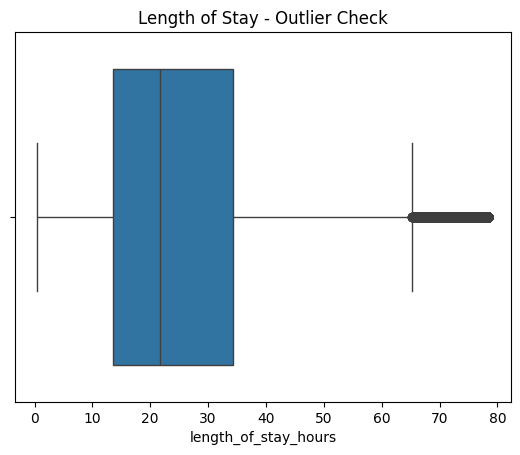

In [171]:
sns.boxplot(x=df["length_of_stay_hours"])
plt.title("Length of Stay - Outlier Check")
plt.show()

In [172]:
df=pd.read_csv("../outputs/model_table.csv")
for col in ["length_of_stay_hours", "billed_amount", "payment_days"]:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}")
    print(f"  Q1 = {Q1:.1f}  |  Q3 = {Q3:.1f}  |  IQR = {IQR:.1f}")
    print(f"  Lower bound = {lower:.1f}  |  Upper bound = {upper:.1f}")
    print(f"  Outliers    = {n_out} rows")
    print()

length_of_stay_hours
  Q1 = 13.5  |  Q3 = 34.2  |  IQR = 20.7
  Lower bound = -17.5  |  Upper bound = 65.2
  Outliers    = 1136 rows

billed_amount
  Q1 = 14568.7  |  Q3 = 59710.5  |  IQR = 45141.8
  Lower bound = -53144.0  |  Upper bound = 127423.3
  Outliers    = 0 rows

payment_days
  Q1 = 16.0  |  Q3 = 43.0  |  IQR = 27.0
  Lower bound = -24.5  |  Upper bound = 83.5
  Outliers    = 0 rows



## Note

In the medical domain, negative lower bounds are not considered meaningful, so the lower bound is typically capped at 0.

## Feature Correlations

# We encode the target variables numerically so we can measure correlation.

- `risk_score`  → Low=0, Medium=1, High=2
- `claim_status` → Paid=0, Pending=1, Rejected=2

In [173]:
df["risk_numeric"] = df["risk_score"].map({"Low": 0, "Medium": 1, "High": 2})
df["claim_status_numeric"] = df["claim_status"].map({"Paid": 0, "Pending": 1, "Rejected": 2})
print("risk_numeric :",  {"Low": 0, "Medium": 1, "High": 2})
print("claim_numeric :", {"Paid": 0, "Pending": 1, "Rejected": 2})


risk_numeric : {'Low': 0, 'Medium': 1, 'High': 2}
claim_numeric : {'Paid': 0, 'Pending': 1, 'Rejected': 2}


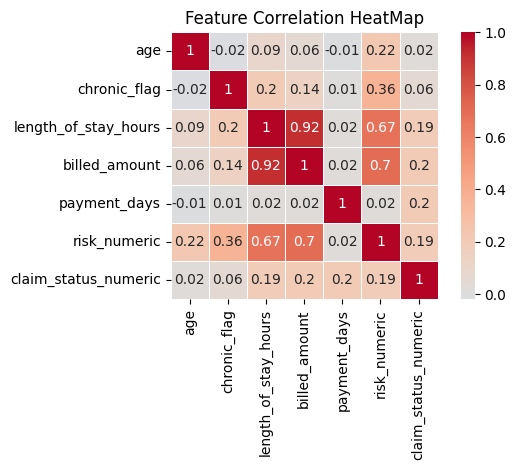

In [174]:

# Full correlation heatmap
numeric_cols = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",
    "payment_days",
    "risk_numeric",
    "claim_status_numeric"
]
corr = df[numeric_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidth=0.5, square=True)
plt.title("Feature Correlation HeatMap")
plt.tight_layout()
plt.show()


In [175]:
corr_risk = corr["risk_numeric"].drop("risk_numeric")

print("Correlation with risk_score (sorted):")
print(corr_risk.sort_values(ascending=False).round(3))

Correlation with risk_score (sorted):
billed_amount           0.70
length_of_stay_hours    0.67
chronic_flag            0.36
age                     0.22
claim_status_numeric    0.19
payment_days            0.02
Name: risk_numeric, dtype: float64


In [176]:
corr_claim = corr["claim_status_numeric"].drop("claim_status_numeric")

print("Correlation with claim_status (sorted):")
print(corr_claim.sort_values(ascending=False).round(3))

Correlation with claim_status (sorted):
billed_amount           0.20
payment_days            0.20
length_of_stay_hours    0.19
risk_numeric            0.19
chronic_flag            0.06
age                     0.02
Name: claim_status_numeric, dtype: float64


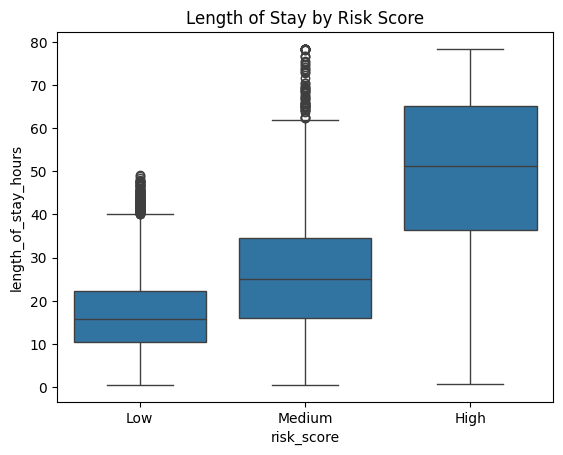


Mean LOS by Risk Score:
risk_score
High      50.69
Low       16.92
Medium    26.10
Name: length_of_stay_hours, dtype: float64


In [177]:
sns.boxplot(data=df, x="risk_score", y="length_of_stay_hours",order=["Low", "Medium", "High"])
plt.title("Length of Stay by Risk Score")
plt.show()
print("\nMean LOS by Risk Score:")
print(df.groupby("risk_score")["length_of_stay_hours"]
  .mean().round(2))

Rejection Rate by Insurance Provider (%):
insurance_provider
CareOne       25.7
MediCareX     24.3
HealthPlus    18.7
SecureLife    15.7
Name: is_rejected, dtype: float64


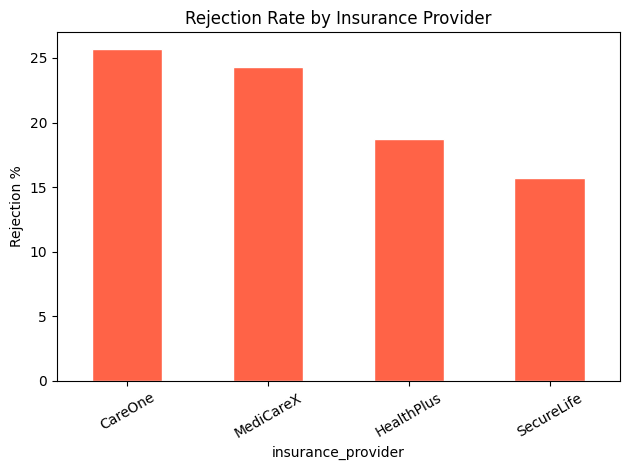

In [178]:
df["is_rejected"] = (df["claim_status"] == "Rejected").astype(int)

rej_rate = (df.groupby("insurance_provider")["is_rejected"]
            .mean()
            .sort_values(ascending=False)
            .mul(100)
            .round(1))

print("Rejection Rate by Insurance Provider (%):")
print(rej_rate)

rej_rate.plot(kind="bar", color="tomato", edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 7 — Feature Engineering

We create 7 new features from the existing columns.  
These features encode **patient behaviour** and **provider patterns**  
that the raw columns cannot express on their own.

| Feature | Logic | Why it matters |
|---|---|---|
| days_since_registration | visit_date − registration_date | Long-term patients behave differently |
| visit_frequency | count of visits per patient | Frequent visitors = higher utilisation |
| avg_los_per_patient | mean LOS per patient | Patient-level health baseline |
| is_rejected | 1 if Rejected else 0 | Helper for rejection rate |
| provider_rejection_rate | mean rejection per insurer | Encodes insurer behaviour |
| visit_month | month from visit_date | Seasonality signal |
| visit_dayofweek | day of week from visit_date | Operational pattern |
| high_cost_visit_flag | billed > 75th percentile | Flags expensive visits |

In [179]:

df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] =pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

In [180]:
# Days since registration
df["days_since_registration"] = abs(
    df["visit_date"] - df["registration_date"]
).dt.days

df[["patient_id", "visit_date",
    "registration_date", "days_since_registration"]].head()

,patient_id,visit_date,registration_date,days_since_registration
0,2,2026-01-01,2025-12-27,5
1,12,2026-01-01,2025-08-13,141
2,129,2026-01-01,2025-07-20,165
3,133,2026-01-01,2025-11-02,60
4,139,2026-01-01,2025-02-05,330


In [181]:
# Visit frequency per patient
df["visit_frequency"] = df.groupby("patient_id")["visit_id"].transform("count")

df[["patient_id", "visit_frequency"]].drop_duplicates().head(10)


,patient_id,visit_frequency
0,2,4
1,12,8
2,129,3
3,133,3
4,139,9
5,170,6
6,216,5
7,222,5
8,243,9
9,335,5


In [182]:
# Average LOS per patient
df["avg_los_per_patient"] = df.groupby("patient_id")["length_of_stay_hours"].transform("mean")

df[["patient_id", "length_of_stay_hours",
    "avg_los_per_patient"]].head()

,patient_id,length_of_stay_hours,avg_los_per_patient
0,2,9.63,21.120000
1,12,59.60,23.750000
2,129,59.28,32.460000
3,133,25.15,30.056667
4,139,42.88,29.030000


In [183]:
# Provider rejection rate

df["provider_rejection_rate"] = df.groupby("insurance_provider")["is_rejected"].transform("mean")

print("Rejection rate per provider:")
print(df.groupby("insurance_provider")["provider_rejection_rate"]
      .first().round(3))

Rejection rate per provider:
insurance_provider
CareOne       0.257
HealthPlus    0.187
MediCareX     0.243
SecureLife    0.157
Name: provider_rejection_rate, dtype: float64


In [184]:
# Time-based features
df["visit_month"]      = df["visit_date"].dt.month
df["visit_dayofweek"]  = df["visit_date"].dt.dayofweek

df[["visit_date", "visit_month", "visit_dayofweek"]].head()

,visit_date,visit_month,visit_dayofweek
0,2026-01-01,1,3
1,2026-01-01,1,3
2,2026-01-01,1,3
3,2026-01-01,1,3
4,2026-01-01,1,3


In [185]:
# High cost visit flag — top 25% of billed amount
high_cost_threshold = df["billed_amount"].quantile(0.75)
df["high_cost_visit_flag"] = (df["billed_amount"] > high_cost_threshold).astype(int)

print(f"High cost threshold (75th percentile): ₹{high_cost_threshold:,.0f}")
print()
print(df["high_cost_visit_flag"].value_counts())

High cost threshold (75th percentile): ₹59,711

high_cost_visit_flag
0    18750
1     6250
Name: count, dtype: int64


In [186]:
# Final feature check
new_features = [
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

print("New features added:")
for f in new_features:
    print(f"  ✓ {f}")

print(f"\nFinal dataset shape: {df.shape}")

New features added:
  ✓ days_since_registration
  ✓ visit_frequency
  ✓ avg_los_per_patient
  ✓ provider_rejection_rate
  ✓ visit_month
  ✓ visit_dayofweek
  ✓ high_cost_visit_flag

Final dataset shape: (25000, 30)


In [187]:
df[new_features].describe().round(2)

,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,91.66,6.04,26.03,0.21,7.57,2.98,0.25
std,80.65,2.39,8.48,0.04,4.10,2.02,0.43
min,1.00,1.00,0.50,0.16,1.00,0.00,0.00
25%,25.00,4.00,20.06,0.19,4.00,1.00,0.00
50%,69.00,6.00,25.13,0.19,9.00,3.00,0.00
75%,140.00,8.00,30.82,0.26,11.00,5.00,0.25
max,363.00,14.00,78.42,0.26,12.00,6.00,1.00


In [188]:
df.to_csv("../outputs/model_table.csv", index=False)

print("model_table.csv saved ✓")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nReady for Phase 3 — Modeling")

model_table.csv saved ✓
Shape  : (25000, 30)
Columns: ['patient_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date', 'risk_numeric', 'claim_status_numeric', 'is_rejected', 'days_since_registration', 'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate', 'visit_month', 'visit_dayofweek', 'high_cost_visit_flag']

Ready for Phase 3 — Modeling
